In [16]:
pip install numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [17]:
import numpy as np
import pandas as pd 

In [18]:
df_coffee = pd.read_csv('Data/Daily/coffe_price(2).csv')
df_coffee.head()

,Ngày,Lần cuối,Mở,Cao,Thấp,KL,% Thay đổi
0,28/01/2026,"4,148.00","4,330.00","4,330.00","4,098.00",NaN,1.17%
1,27/01/2026,"4,100.00","4,022.00","4,127.00","3,993.00",4.87K,-0.32%
2,26/01/2026,"4,113.00","4,039.00","4,145.00","4,026.00",9.36K,1.53%
3,23/01/2026,"4,051.00","3,947.00","4,114.00","3,939.00",13.26K,2.74%
4,22/01/2026,"3,943.00","3,960.00","3,974.00","3,921.00",9.38K,-1.03%


In [19]:
# Transfer "Ngay" column to datetime format
df_coffee['Ngày'] = pd.to_datetime(df_coffee['Ngày'], format='%d/%m/%Y')
df_coffee.head()

,Ngày,Lần cuối,Mở,Cao,Thấp,KL,% Thay đổi
0,2026-01-28,"4,148.00","4,330.00","4,330.00","4,098.00",NaN,1.17%
1,2026-01-27,"4,100.00","4,022.00","4,127.00","3,993.00",4.87K,-0.32%
2,2026-01-26,"4,113.00","4,039.00","4,145.00","4,026.00",9.36K,1.53%
3,2026-01-23,"4,051.00","3,947.00","4,114.00","3,939.00",13.26K,2.74%
4,2026-01-22,"3,943.00","3,960.00","3,974.00","3,921.00",9.38K,-1.03%


In [20]:
df_coffee['Lần cuối'] = df_coffee['Lần cuối'].str.replace(',', '').astype(float)
df_coffee.head()
# Máy không hiểu được các số có dấu .

,Ngày,Lần cuối,Mở,Cao,Thấp,KL,% Thay đổi
0,2026-01-28,4148.0,"4,330.00","4,330.00","4,098.00",NaN,1.17%
1,2026-01-27,4100.0,"4,022.00","4,127.00","3,993.00",4.87K,-0.32%
2,2026-01-26,4113.0,"4,039.00","4,145.00","4,026.00",9.36K,1.53%
3,2026-01-23,4051.0,"3,947.00","4,114.00","3,939.00",13.26K,2.74%
4,2026-01-22,3943.0,"3,960.00","3,974.00","3,921.00",9.38K,-1.03%


In [21]:
df_coffee = df_coffee[['Ngày', 'Lần cuối', 'KL']]
df_coffee.head()
# Bởi vì 3 cột mở, cao, thấp không có nhiều giá trị, mình chỉ cần một data lần cuối là được
# Tiếp nữa là data "thay đổi" cũng không cần bởi vì mô hình tự tính được cái đấy. 

,Ngày,Lần cuối,KL
0,2026-01-28,4148.0,NaN
1,2026-01-27,4100.0,4.87K
2,2026-01-26,4113.0,9.36K
3,2026-01-23,4051.0,13.26K
4,2026-01-22,3943.0,9.38K


In [22]:
df_coffee = df_coffee.rename(columns={'Ngày': 'Date', 'Lần cuối': 'Last Price', 'KL': 'Volume'})

In [23]:
df_coffee = df_coffee.sort_values('Date').reset_index(drop=True)
df_coffee.head()

,Date,Last Price,Volume
0,2008-01-14,2051.0,NaN
1,2008-01-15,2036.0,NaN
2,2008-01-16,2040.0,0.00K
3,2008-01-17,2037.0,NaN
4,2008-01-18,2027.0,NaN


In [24]:
def clean_volume(vol): 
    if pd.isna(vol) or vol == '':
        return 0.0
    vol = str(vol).strip().upper()
    mult = 1.0 
    if 'K' in vol:
        mult = 1000.0
        vol = vol.replace('K', '')
    elif 'M' in vol:
        mult = 1000000.0
        vol = vol.replace('M', '')

    try:
        return float(vol) * mult
    except ValueError:
        return 0.0

In [25]:
df_coffee['Volume'] = df_coffee['Volume'].apply(clean_volume)
df_coffee.tail()

,Date,Last Price,Volume
4598,2026-01-22,3943.0,9380.0
4599,2026-01-23,4051.0,13260.0
4600,2026-01-26,4113.0,9360.0
4601,2026-01-27,4100.0,4870.0
4602,2026-01-28,4148.0,0.0


Oke done coffee data

In [28]:
import dis

import pandas as pd

def load_macro_data(filepath, value_col_name):
    
    df = pd.read_csv(filepath)
    # Đồng bộ hóa tên cột ngày
    df['Date'] = pd.to_datetime(df['observation_date'])
    
    val_col = df.columns[1] # Lấy cột giá trị
    
    # Xử lý dấu phẩy thập phân 
    if df[val_col].dtype == 'string':
        df[val_col] = df[val_col].astype(str).str.replace(',', '.').astype(float)
        
    df = df[['Date', val_col]]
    df.rename(columns={val_col: value_col_name}, inplace=True)
    return df

# load 3 file
df_usd = load_macro_data('Data/Daily/USD_INDEX.csv', 'USD_Index')
df_effr = load_macro_data('Data/Daily/EFFR.csv', 'EFFR')
df_oil = load_macro_data('Data/Daily/Crude Oil Prices Daily.csv', 'Crude_Oil')

display(df_usd.head())
display(df_effr.head())
display(df_oil.head())


,Date,USD_Index
0,2008-01-14,89.2749
1,2008-01-15,89.1555
2,2008-01-16,89.6701
3,2008-01-17,89.6484
4,2008-01-18,89.8993


,Date,EFFR
0,2008-01-14,4.24
1,2008-01-15,4.24
2,2008-01-16,4.22
3,2008-01-17,4.23
4,2008-01-18,4.17


,Date,Crude_Oil
0,2008-01-14,94.23
1,2008-01-15,91.87
2,2008-01-16,90.80
3,2008-01-17,90.11
4,2008-01-18,90.55


In [29]:
# Ghép các bảng 
# Lấy df_coffee làm gốc để giữ nguyên lịch giao dịch của sàn cà phê
df_final = df_coffee.merge(df_usd, on='Date', how='left')
df_final = df_final.merge(df_effr, on='Date', how='left')
df_final = df_final.merge(df_oil, on='Date', how='left')

# 2. Xử lý missing values
# Lấy giá trị ngày hôm trước điền cho ngày nghỉ lễ hoặc các ngày trống. Bởi vì mình dùng data caffee của london còn giá dầu hay usd lại của mỹ nên sẽ có những ngày sàn london mở nhưng mỹ lại đóng. Nên mình phải lấy giá trị của ngày trước, không thể để 0, cũng không thể lấy trung bình cộng. 
df_final = df_final.ffill()

# Xóa các dòng NaN còn sót lại ở đầu. Bởi ngày đầu tiên thì không có giá trị ngày trước để điền nên sẽ luôn bị Nan, nên xóa đi. 
df_final = df_final.dropna()

# 4. Xuất kết quả
df_final.to_csv('Cleaned_Multivariate_Data.csv', index=False)

print(df_final.head())

        Date  Last Price  Volume  USD_Index  EFFR  Crude_Oil
0 2008-01-14      2051.0     0.0    89.2749  4.24      94.23
1 2008-01-15      2036.0     0.0    89.1555  4.24      91.87
2 2008-01-16      2040.0     0.0    89.6701  4.22      90.80
3 2008-01-17      2037.0     0.0    89.6484  4.23      90.11
4 2008-01-18      2027.0     0.0    89.8993  4.17      90.55


In [31]:
pip install matplotlib statsmodels scikit-learn

  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 110.4 kB/s  0:01:55 eta 0:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 194.3 kB/s  0:00:52m0:00:010:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 192.9 kB/s  0:00:53m0:00:0100:03
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 208.3 kB/s  0:00:12 eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 174.1 kB/s  0:00:27 eta 0:00:02
   ━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/20.3 MB 77.7 kB/s eta 0:03:08
Resuming download scipy-1.17.1-cp313-cp313-macosx_14_0_arm64.whl (5.8 MB/20.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 1.1 

In [34]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.9/591.9 kB 2.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 3.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pmdarima]
Note: you may need to restart the kernel to use updated packages.


In [42]:
import pandas as pd
import numpy as np
import pmdarima as pm
import matplotlib.pyplot as plt

# 1. Load file
df = pd.read_csv('Data/Daily/Cleaned_Multivariate_Data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

series = df['Last Price'] 

# 2. Chia tập Train/Test (80/20)
train_size = int(len(series) * 0.8)
train, test = series.iloc[:train_size], series.iloc[train_size:]

print("Bắt đầu khởi động thuật toán dò mìn Auto-ARIMA...")

# 3. Ép máy tính tự tìm (p, d, q) tối ưu nhất
auto_model = pm.auto_arima(train, 
                           start_p=1, start_q=1,
                           max_p=7, max_q=7, # Cho phép dò tối đa 7 ngày quá khứ
                           m=1,              # Dữ liệu ngày, không có chu kỳ mùa vụ cố định
                           d=None,           # Để nó tự dùng kiểm định ADF tìm bậc sai phân
                           seasonal=False,   # Đang chạy ARIMA thuần, không phải SARIMA
                           trace=True,       # BẬT CÁI NÀY LÊN ĐỂ LẤY LOG CHO BÀI BÁO
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True)    # Dùng thuật toán tối ưu để chạy nhanh hơn

print("\n" + "="*50)
print("BỘ CHỈ SỐ (p,d,q) TỐI ƯU!")
print(auto_model.summary())



Bắt đầu khởi động thuật toán dò mìn Auto-ARIMA...
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=35018.425, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=35024.669, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=35017.408, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=35017.001, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=35022.671, Time=0.01 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=35017.766, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=35017.971, Time=0.26 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=35015.002, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=35016.426, Time=0.04 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=35015.768, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=35015.409, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=35015.973, Time=0.17 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 0.799 seconds

BỘ CHỈ SỐ (p,d,q) TỐI ƯU!

Số ngày Train: 3682 | Số ngày Test: 921

ARIMA đang train data...
Đang dự báo tương lai...

=== KẾT QUẢ TEST CỦA ARIMA MODEL (BASELINE) ===
Lỗi bình phương trung bình (RMSE) : 1773.64 USD
Sai số tuyệt đối trung bình (MAE) : 1371.76 USD
Tỷ lệ sai số phần trăm (MAPE)     : 32.91 %


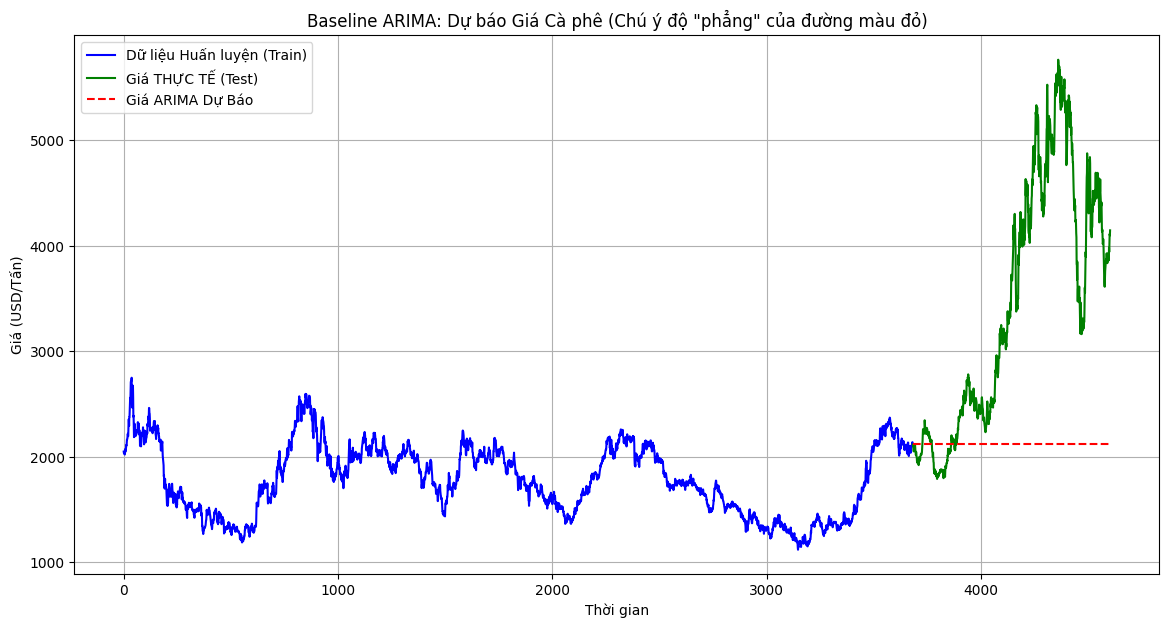

In [36]:

import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore') 

df = pd.read_csv('Data/Daily/Cleaned_Multivariate_Data.csv')


# Chạy mô hình Arima trên cột "Last Price" (Giá cà phê), bởi vì đây là mô hình tuyến tính đơn biến, nên mình chỉ có thể dùng một cột giá trị để dự báo. Còn các cột khác như USD, EFFR, Dầu thì mình sẽ dùng để huấn luyện mô hình hồi quy sau này.
series = df['Last Price']

# 2. Chia tập Train/Test (80/20)
train_size = int(len(series) * 0.8)
train, test = series.iloc[:train_size], series.iloc[train_size:]

print(f"Số ngày Train: {len(train)} | Số ngày Test: {len(test)}")

# 3. Khởi tạo và Huấn luyện ARIMA
# Lưu ý: Bộ tham số order=(5, 1, 0) ở đây là tao đang gán cứng để chạy thử.
# (Tức là: dùng 5 ngày quá khứ (p=5), lấy sai phân bậc 1 (d=1), không dùng trung bình trượt (q=0)).
print("\nARIMA đang train data...")
model = ARIMA(train, order=(0, 1, 1)) 
model_fit = model.fit()

# 4. Giai đoạn dự báo (Forecasting)
print("Đang dự báo tương lai...")
predictions = model_fit.forecast(steps=len(test))

# 5. Chấm điểm accuracy của mô hình ARIMA bằng các chỉ số RMSE, MAE, MAPE
rmse = np.sqrt(mean_squared_error(test, predictions))
mae = mean_absolute_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions) * 100

print(f"\n=== KẾT QUẢ TEST CỦA ARIMA MODEL (BASELINE) ===")
print(f"Lỗi bình phương trung bình (RMSE) : {rmse:.2f} USD")
print(f"Sai số tuyệt đối trung bình (MAE) : {mae:.2f} USD")
print(f"Tỷ lệ sai số phần trăm (MAPE)     : {mape:.2f} %")

# 6. Vẽ biểu đồ mô hình
plt.figure(figsize=(14, 7))
plt.plot(train.index, train, label='Dữ liệu Huấn luyện (Train)', color='blue')
plt.plot(test.index, test, label='Giá THỰC TẾ (Test)', color='green')
plt.plot(test.index, predictions, color='red', label='Giá ARIMA Dự Báo', linestyle='--')

plt.title('Baseline ARIMA: Dự báo Giá Cà phê (Chú ý độ "phẳng" của đường màu đỏ)')
plt.xlabel('Thời gian')
plt.ylabel('Giá (USD/Tấn)')
plt.legend()
plt.grid(True)
plt.show()

Kích thước X_train: (3633, 60, 5) | X_test: (909, 60, 5)

Đang khởi động mạng Neural Network...
Đang ép LSTM học 5 biến vĩ mô...
Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0015 - val_loss: 3.2647e-04
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.4523e-04 - val_loss: 2.6973e-04
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5561e-04 - val_loss: 1.8953e-04
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7491e-04 - val_loss: 2.8790e-04
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7370e-04 - val_loss: 3.0542e-04
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4584e-04 - val_loss: 1.3061e-04
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9513e-04 - val_loss: 3.2711e-04
Epoch 8/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6476e-04 - val_loss: 1.5861e-04
Epoch 9/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5645e-04 - val_loss: 1.1367e-04
Epoch 10/30
103/103 

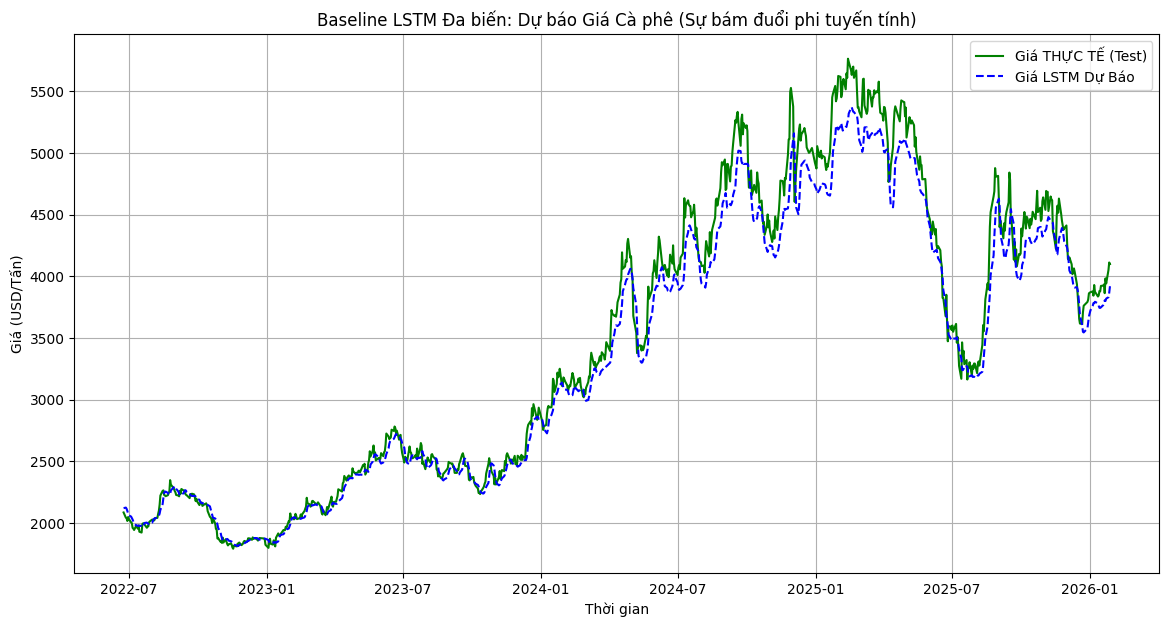

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# 1. Load file
df = pd.read_csv('Data/Daily/Cleaned_Multivariate_Data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Lấy 5 biến (Chú ý: Cột mục tiêu 'Last Price' phải để đầu tiên)
features = ['Last Price', 'Volume', 'USD_Index', 'EFFR', 'Crude_Oil']
data = df[features].values

# 2. Chuẩn hóa dữ liệu (Scaling) - Ép tất cả về khoảng [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Chế tạo cửa sổ thời gian (Windowing)
# Chiến lược: Nhìn 60 ngày quá khứ để dự đoán 1 ngày tương lai
time_step = 60

def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), :] # Lấy cả 5 cột trong 60 ngày
        X.append(a)
        Y.append(dataset[i + time_step, 0]) # Chỉ dự báo cột 0 (Last Price)
    return np.array(X), np.array(Y)

X, y = create_dataset(scaled_data, time_step)

# 4. Chia Train/Test (Phải chia đúng tỷ lệ 80/20 để công bằng với ARIMA)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Kích thước X_train: {X_train.shape} | X_test: {X_test.shape}")

# 5. Xây dựng bộ khung LSTM (Kiến trúc Deep Learning)
print("\nĐang khởi động mạng Neural Network...")
model = Sequential()
# Lớp 1
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2)) # Chống học vẹt (Overfitting)
# Lớp 2
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
# Lớp chốt hạ ra kết quả
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# 6. Training
print("Đang ép LSTM học 5 biến vĩ mô...")
# batch_size=32, epochs=50 là tiêu chuẩn vừa đủ để test nhanh
history = model.fit(X_train, y_train, validation_split=0.1, epochs=30, batch_size=32, verbose=1)

# 7. Test
print("\nĐang dự báo tương lai...")
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# 8. Giải mã dữ liệu (Inverse Transform) - Đưa từ [0,1] về lại tiền USD
# Phải tạo ma trận giả (dummy) để đảo ngược scale vì scaler lúc đầu fit 5 cột
dummy_test_pred = np.zeros((len(test_predict), len(features)))
dummy_test_pred[:, 0] = test_predict[:, 0]
test_predict_usd = scaler.inverse_transform(dummy_test_pred)[:, 0]

dummy_y_test = np.zeros((len(y_test), len(features)))
dummy_y_test[:, 0] = y_test
y_test_usd = scaler.inverse_transform(dummy_y_test)[:, 0]

# 9. Chấm điểm Baseline LSTM
rmse = np.sqrt(mean_squared_error(y_test_usd, test_predict_usd))
mae = mean_absolute_error(y_test_usd, test_predict_usd)
mape = mean_absolute_percentage_error(y_test_usd, test_predict_usd) * 100

print(f"\n=== KẾT QUẢ BÀI THI CỦA LSTM (BASELINE ĐA BIẾN) ===")
print(f"Lỗi bình phương trung bình (RMSE) : {rmse:.2f} USD")
print(f"Sai số tuyệt đối trung bình (MAE) : {mae:.2f} USD")
print(f"Tỷ lệ sai số phần trăm (MAPE)     : {mape:.2f} %")

# 10. Vẽ biểu đồ
plt.figure(figsize=(14, 7))
# Khôi phục trục thời gian chuẩn cho đồ thị
test_dates = df.index[-len(y_test):]

plt.plot(test_dates, y_test_usd, label='Giá THỰC TẾ (Test)', color='green')
plt.plot(test_dates, test_predict_usd, label='Giá LSTM Dự Báo', color='blue', linestyle='--')

plt.title('Baseline LSTM Đa biến: Dự báo Giá Cà phê (Sự bám đuổi phi tuyến tính)')
plt.xlabel('Thời gian')
plt.ylabel('Giá (USD/Tấn)')
plt.legend()
plt.grid(True)
plt.show()

=== GIAI ĐOẠN 1: CHUẨN BỊ ===
Số dòng Train: 3682 | Số dòng Test: 921

=== GIAI ĐOẠN 2: ARIMA  ===

=== GIAI ĐOẠN 3:LSTM HỌC PHẦN DƯ ĐA BIẾN ===
Đang huấn luyện AI trên Phần dư và Vĩ mô...

=== GIAI ĐOẠN 4: KẾT HỢP ===
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

=== KẾT QUẢ TEST CỦA MODEL HYBRID (ARIMA + LSTM) ===
Lỗi bình phương trung bình (RMSE) : 109.89 USD
Sai số tuyệt đối trung bình (MAE) : 61.22 USD
Tỷ lệ sai số phần trăm (MAPE)     : 1.73 %


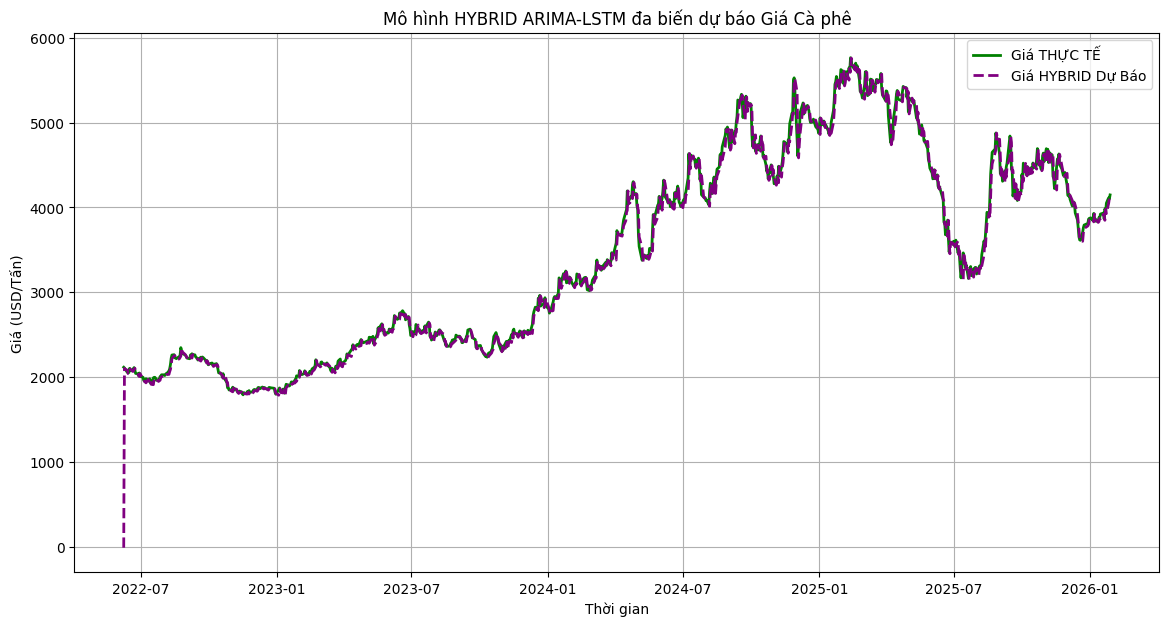

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

print("=== GIAI ĐOẠN 1: CHUẨN BỊ ===")
df = pd.read_csv('Data/Daily/Cleaned_Multivariate_Data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Chia Train/Test (80/20) 
train_size = int(len(df) * 0.8)
train_df, test_df = df.iloc[:train_size], df.iloc[train_size:]

train_price = train_df['Last Price']
test_price = test_df['Last Price']

print(f"Số dòng Train: {len(train_df)} | Số dòng Test: {len(test_df)}")


print("\n=== GIAI ĐOẠN 2: ARIMA  ===")
# Fit mô hình trên tập Train như bình thường
arima_model = ARIMA(train_price, order=(0, 1, 1))
arima_result = arima_model.fit()

# 1. Phần dư tập Train (Dự báo trượt 1-bước)
train_df['ARIMA_Pred'] = arima_result.fittedvalues
train_df['Residuals'] = train_price - train_df['ARIMA_Pred']

# 2. KHÔNG DÙNG FORECAST NỮA! 
# Dùng hàm APPLY để bắt ARIMA trượt từng ngày một trên tập Test y như LSTM
test_arima_applied = arima_result.apply(test_price)
test_df['ARIMA_Pred'] = test_arima_applied.fittedvalues

# Bây giờ Phần dư ở tập Test cũng sẽ nhỏ xíu (nhiễu trắng) y như tập Train
test_df['Residuals'] = test_price - test_df['ARIMA_Pred']

print("\n=== GIAI ĐOẠN 3:LSTM HỌC PHẦN DƯ ĐA BIẾN ===")
# Nối lại để làm dữ liệu chuỗi liên tục cho LSTM
full_df = pd.concat([train_df, test_df])

# Tầm nhìn chiến lược: AI BÂY GIỜ CHỈ NHÌN VÀO CỘT RESIDUALS, KHÔNG NHÌN CỘT PRICE NỮA!
features = ['Residuals', 'Volume', 'USD_Index', 'EFFR', 'Crude_Oil']
data = full_df[features].values

# Chuẩn hóa (Scale)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Chế tạo cửa sổ thời gian (60 ngày quá khứ)
time_step = 60
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:(i + time_step), :])
        Y.append(dataset[i + time_step, 0]) # Dự báo cột 0 (Tức là dự báo Residuals)
    return np.array(X), np.array(Y)

X, y = create_dataset(scaled_data, time_step)

# Do mất 60 ngày đầu để làm cửa sổ, tập Train sẽ bị thụt đi một chút
X_train, X_test = X[:train_size - time_step], X[train_size - time_step:]
y_train, y_test = y[:train_size - time_step], y[train_size - time_step:]

# Xây dựng kiến trúc LSTM
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

print("Đang huấn luyện AI trên Phần dư và Vĩ mô...")
model.fit(X_train, y_train, validation_split=0.1, epochs=30, batch_size=32, verbose=0)


print("\n=== GIAI ĐOẠN 4: KẾT HỢP ===")
# LSTM dự báo Phần dư cho tập Test
lstm_scaled_pred = model.predict(X_test)

# Đảo ngược Scale để lấy lại giá trị Phần dư bằng USD
dummy_test_pred = np.zeros((len(lstm_scaled_pred), len(features)))
dummy_test_pred[:, 0] = lstm_scaled_pred[:, 0]
lstm_residual_pred = scaler.inverse_transform(dummy_test_pred)[:, 0]

# GHI NHỚ NGUYÊN LÝ ZHANG (2003): GIÁ LAI = GIÁ ARIMA + PHẦN DƯ LSTM
# Lưu ý: Cắt bỏ 60 ngày đầu của test_arima_pred để khớp với độ dài của lstm_residual_pred
final_hybrid_pred = test_df['ARIMA_Pred'].values + lstm_residual_pred

# Lấy giá thực tế ra để chấm điểm
actual_test_price = test_price.values

# Chấm điểm Mô hình Lai
rmse = np.sqrt(mean_squared_error(actual_test_price, final_hybrid_pred))
mae = mean_absolute_error(actual_test_price, final_hybrid_pred)
mape = mean_absolute_percentage_error(actual_test_price, final_hybrid_pred) * 100

print(f"\n=== KẾT QUẢ TEST CỦA MODEL HYBRID (ARIMA + LSTM) ===")
print(f"Lỗi bình phương trung bình (RMSE) : {rmse:.2f} USD")
print(f"Sai số tuyệt đối trung bình (MAE) : {mae:.2f} USD")
print(f"Tỷ lệ sai số phần trăm (MAPE)     : {mape:.2f} %")

# Vẽ biểu đồ 
plt.figure(figsize=(14, 7))
test_dates = df.index[-len(actual_test_price):]

plt.plot(test_dates, actual_test_price, label='Giá THỰC TẾ', color='green', linewidth=2)
plt.plot(test_dates, final_hybrid_pred, label='Giá HYBRID Dự Báo', color='purple', linestyle='--', linewidth=2)

plt.title('Mô hình HYBRID ARIMA-LSTM đa biến dự báo Giá Cà phê')
plt.xlabel('Thời gian')
plt.ylabel('Giá (USD/Tấn)')
plt.legend()
plt.grid(True)
plt.show()